Inserted error = X
Error on physical qubit = 4

Original state:
Statevector([0.8236391 -0.26761657j, 0.47552826+0.1545085j ],
            dims=(2,))

Recovered logical qubit:
DensityMatrix([[0.75      -2.59634946e-18j, 0.35031463-2.54518480e-01j],
               [0.35031463+2.54518480e-01j, 0.25      +4.80779204e-18j]],
              dims=(2,))

Fidelity = 0.9999999999999988


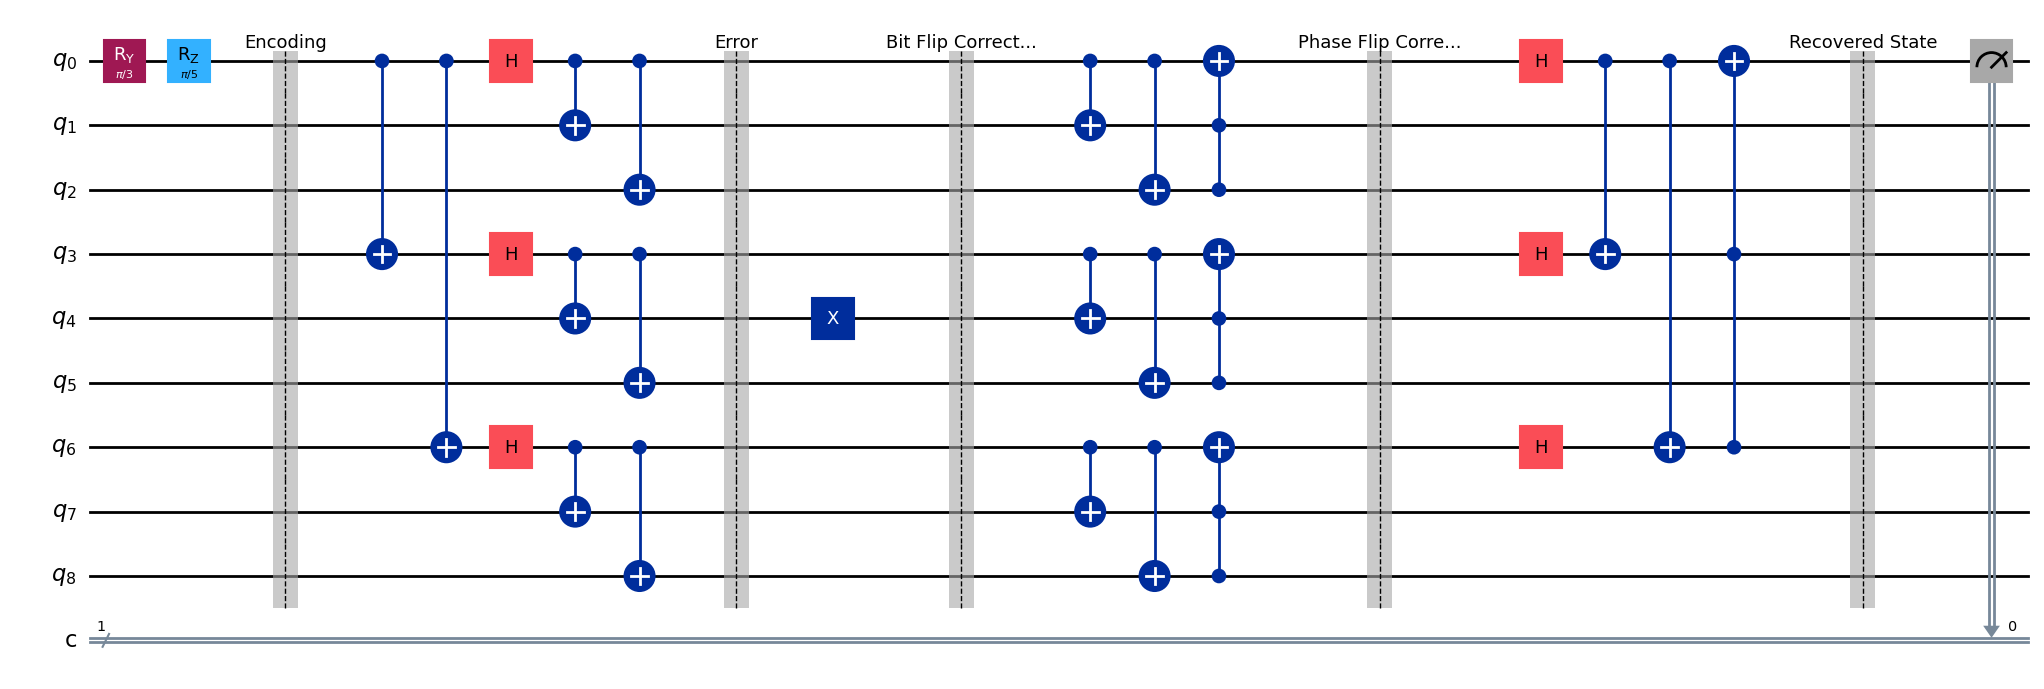


Testing all single-qubit X errors
X error on q 0   Fidelity = 1.0
X error on q 1   Fidelity = 1.0
X error on q 2   Fidelity = 1.0
X error on q 3   Fidelity = 1.0
X error on q 4   Fidelity = 1.0
X error on q 5   Fidelity = 1.0
X error on q 6   Fidelity = 1.0
X error on q 7   Fidelity = 1.0
X error on q 8   Fidelity = 1.0

Testing all single-qubit Z errors
Z error on q 0   Fidelity = 1.0
Z error on q 1   Fidelity = 1.0
Z error on q 2   Fidelity = 1.0
Z error on q 3   Fidelity = 1.0
Z error on q 4   Fidelity = 1.0
Z error on q 5   Fidelity = 1.0
Z error on q 6   Fidelity = 1.0
Z error on q 7   Fidelity = 1.0
Z error on q 8   Fidelity = 1.0

Testing all single-qubit Y errors
Y error on q 0   Fidelity = 1.0
Y error on q 1   Fidelity = 1.0
Y error on q 2   Fidelity = 1.0
Y error on q 3   Fidelity = 1.0
Y error on q 4   Fidelity = 1.0
Y error on q 5   Fidelity = 1.0
Y error on q 6   Fidelity = 1.0
Y error on q 7   Fidelity = 1.0
Y error on q 8   Fidelity = 1.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity


def prepare_logical_state(qc, theta, phi):
    qc.ry(theta, 0)
    qc.rz(phi, 0)


def shor_encode(qc):
    # Outer 3-qubit encoding for phase-flip protection
    qc.cx(0, 3)
    qc.cx(0, 6)

    qc.h(0)
    qc.h(3)
    qc.h(6)

    # Inner 3-qubit repetition blocks for bit-flip protection
    qc.cx(0, 1)
    qc.cx(0, 2)

    qc.cx(3, 4)
    qc.cx(3, 5)

    qc.cx(6, 7)
    qc.cx(6, 8)


def apply_single_qubit_error(qc, error_type, error_qubit):
    if error_type == "X":
        qc.x(error_qubit)

    elif error_type == "Z":
        qc.z(error_qubit)

    elif error_type == "Y":
        qc.y(error_qubit)

    elif error_type == "I":
        pass

    else:
        raise ValueError(
            "error_type must be 'I', 'X', 'Y', or 'Z'"
        )


def correct_bit_flips(qc):
    # Block 1: q0, q1, q2
    qc.cx(0, 1)
    qc.cx(0, 2)
    qc.ccx(1, 2, 0)

    # Block 2: q3, q4, q5
    qc.cx(3, 4)
    qc.cx(3, 5)
    qc.ccx(4, 5, 3)

    # Block 3: q6, q7, q8
    qc.cx(6, 7)
    qc.cx(6, 8)
    qc.ccx(7, 8, 6)


def correct_phase_flip_and_decode(qc):
    # Convert phase information to computational-basis information
    qc.h(0)
    qc.h(3)
    qc.h(6)

    # Majority vote across the three blocks
    qc.cx(0, 3)
    qc.cx(0, 6)
    qc.ccx(3, 6, 0)


def build_shor_circuit(
    theta=np.pi / 3,
    phi=np.pi / 5,
    error_type="X",
    error_qubit=4
):
    qc = QuantumCircuit(9)

    prepare_logical_state(
        qc,
        theta,
        phi
    )

    qc.barrier(label="Encoding")

    shor_encode(qc)

    qc.barrier(label="Error")

    apply_single_qubit_error(
        qc,
        error_type,
        error_qubit
    )

    qc.barrier(label="Bit Flip Correction")

    correct_bit_flips(qc)

    qc.barrier(label="Phase Flip Correction")

    correct_phase_flip_and_decode(qc)

    qc.barrier(label="Recovered State")

    return qc


theta = np.pi / 3
phi = np.pi / 5

error_type = "X"
error_qubit = 4


original_qc = QuantumCircuit(1)

prepare_logical_state(
    original_qc,
    theta,
    phi
)

original_state = Statevector.from_instruction(
    original_qc
)


qc = build_shor_circuit(
    theta=theta,
    phi=phi,
    error_type=error_type,
    error_qubit=error_qubit
)


final_state = Statevector.from_instruction(qc)


recovered_state = partial_trace(
    final_state,
    list(range(1, 9))
)


fidelity = state_fidelity(
    original_state,
    recovered_state
)


print("Inserted error =", error_type)

print(
    "Error on physical qubit =",
    error_qubit
)

print()

print("Original state:")
print(original_state)

print()

print("Recovered logical qubit:")
print(recovered_state)

print()

print(
    "Fidelity =",
    fidelity
)


display_qc = qc.copy()

classical_register = ClassicalRegister(
    1,
    "c"
)

display_qc.add_register(
    classical_register
)

display_qc.measure(
    0,
    classical_register[0]
)


display(
    display_qc.draw(
        output="mpl",
        fold=-1,
        idle_wires=True
    )
)


print()
print("Testing all single-qubit X errors")

for qubit in range(9):

    test_qc = build_shor_circuit(
        theta=theta,
        phi=phi,
        error_type="X",
        error_qubit=qubit
    )

    test_state = Statevector.from_instruction(
        test_qc
    )

    recovered = partial_trace(
        test_state,
        list(range(1, 9))
    )

    fid = state_fidelity(
        original_state,
        recovered
    )

    print(
        "X error on q",
        qubit,
        "  Fidelity =",
        round(fid, 10)
    )


print()
print("Testing all single-qubit Z errors")

for qubit in range(9):

    test_qc = build_shor_circuit(
        theta=theta,
        phi=phi,
        error_type="Z",
        error_qubit=qubit
    )

    test_state = Statevector.from_instruction(
        test_qc
    )

    recovered = partial_trace(
        test_state,
        list(range(1, 9))
    )

    fid = state_fidelity(
        original_state,
        recovered
    )

    print(
        "Z error on q",
        qubit,
        "  Fidelity =",
        round(fid, 10)
    )


print()
print("Testing all single-qubit Y errors")

for qubit in range(9):

    test_qc = build_shor_circuit(
        theta=theta,
        phi=phi,
        error_type="Y",
        error_qubit=qubit
    )

    test_state = Statevector.from_instruction(
        test_qc
    )

    recovered = partial_trace(
        test_state,
        list(range(1, 9))
    )

    fid = state_fidelity(
        original_state,
        recovered
    )

    print(
        "Y error on q",
        qubit,
        "  Fidelity =",
        round(fid, 10)
    )